# TRABALHO 10 - COMPUTAÇÃO EVOLUTIVA - PPGGE/UFPA
- Discente: Pedro Henrique do Vale Guimarães
- Docente: Dr. Roberto Célio Limão de Oliveira

Execução de Estratégias Evolutivas para otimização global da F6 (Função Schaffer N°2) e comparação com Algoritmo Genético

# Inicialização

In [96]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from itertools import combinations
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Literal
import psutil
import time
import os
import glob

relative = "../"
codes_path = os.path.abspath(relative)

logs_dir = "logs"
results_dir = "results"
os.makedirs(logs_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

In [3]:
# Função de aptidão F6 modificada (10 variáveis)
def f6_v10(x, y, z, a, b, c, d, e, f, g):
    term = x**2 + y**2 + z**2 + a**2 + b**2 + c**2 + d**2 + e**2 + f**2 + g**2
    num = np.sin(np.sqrt(term))**2 - 0.5
    denom = (1 + 0.001 * term)**2
    return 0.5 - num / denom

def evaluate(population):
    return np.array([f6_v10(*ind) for ind in population])

# Função de Fitness Sharing

In [12]:
def fitness_sharing(population, fitness_values, sigma_share, alpha=1):
    """
    Aplica a técnica de Fitness Sharing para ajustar os valores de aptidão.

    Args:
        population (np.ndarray): A população atual de indivíduos (matriz NxD, onde N é o número de indivíduos e D é a dimensão).
        fitness_values (np.ndarray): Os valores de aptidão originais para cada indivíduo.
        sigma_share (float): O raio de compartilhamento. Indivíduos dentro desta distância são considerados similares.
        alpha (float): Parâmetro para controlar a forma da função de compartilhamento (padrão é 1).

    Returns:
        np.ndarray: Os valores de aptidão ajustados após a aplicação do Fitness Sharing.
    """
    num_individuals = population.shape[0]
    # Calcula a matriz de distância euclidiana entre todos os indivíduos
    distances = squareform(pdist(population, metric='euclidean'))

    # calcular métricas de diversidade
    triu = distances[np.triu_indices_from(distances, k=1)]
    diversity_stats = {
        "mean": np.mean(triu),
        "min": np.min(triu),
        "max": np.max(triu)
    }

    # Inicializa a matriz de compartilhamento de nicho
    niche_count = np.zeros(num_individuals)

    # Calcula o número de indivíduos em cada nicho
    for i in range(num_individuals):
        # Encontra indivíduos dentro do raio de compartilhamento
        # A função sh_func é 1 se a distância for menor que sigma_share, e 0 caso contrário
        # sh_func = 1 - (d / sigma_share)**alpha se d < sigma_share, else 0
        # Para simplificar, usaremos uma função triangular comum para sh_func
        sh_values = 1 - (distances[i, :] / sigma_share)**alpha
        sh_values[distances[i, :] >= sigma_share] = 0
        niche_count[i] = np.sum(sh_values)

    # Evita divisão por zero se niche_count for 0 (indivíduo isolado)
    niche_count[niche_count == 0] = 1

    # Ajusta os valores de aptidão
    adjusted_fitness = fitness_values / niche_count

    return adjusted_fitness, diversity_stats

# Função de Mutação Adaptativa

In [73]:
def adaptive_mutation(
    current_sigma, mean_diversity, fitness_history, generation, max_generations, initial_sigma, 
    diversity_threshold_low=5.0, diversity_threshold_high=50.0, fitness_stagnation_window=10, 
    adjustment_factor_increase=1.5, adjustment_factor_decrease=0.7):
    """
    Ajusta a taxa de mutação (sigma) adaptativamente com base na diversidade e no progresso da aptidão.

    Args:
        current_sigma (float): A taxa de mutação atual.
        mean_diversity (float): A diversidade média da população atual.
        fitness_history (list): Histórico dos valores de aptidão máxima ou média ao longo das gerações.
        generation (int): A geração atual.
        max_generations (int): O número total de gerações.
        initial_sigma (float): A taxa de mutação inicial.
        diversity_threshold_low (float): Limiar inferior de diversidade. Se a diversidade cair abaixo, aumenta sigma.
        diversity_threshold_high (float): Limiar superior de diversidade. Se a diversidade estiver acima e o progresso for lento, diminui sigma.
        fitness_stagnation_window (int): Número de gerações para verificar estagnação da aptidão.
        adjustment_factor_increase (float): Fator para aumentar sigma.
        adjustment_factor_decrease (float): Fator para diminuir sigma.

    Returns:
        float: A nova taxa de mutação ajustada.
    """

    new_sigma = current_sigma

    # 1. Ajuste baseado na diversidade
    if mean_diversity < diversity_threshold_low:
        # Aumenta sigma se a diversidade for muito baixa (convergência prematura)
        new_sigma *= adjustment_factor_increase
        # print(f"Geração {generation}: Diversidade baixa ({mean_diversity:.2f}), aumentando sigma para {new_sigma:.4f}")
    elif mean_diversity > diversity_threshold_high:
        # Diminui sigma se a diversidade for muito alta e o progresso for lento (exploração excessiva)
        # Verifica estagnação da aptidão
        if len(fitness_history) >= fitness_stagnation_window:
            recent_fitness = fitness_history[-fitness_stagnation_window:]
            if np.std(recent_fitness) < 1e-5: # Se a aptidão não mudou significativamente
                new_sigma *= adjustment_factor_decrease
                # print(f"Geração {generation}: Diversidade alta ({mean_diversity:.2f}) e aptidão estagnada, diminuindo sigma para {new_sigma:.4f}")

    # 2. Ajuste baseado no progresso da otimização (ex: 1/5 regra para Estratégias Evolutivas)
    # Esta é uma regra mais complexa e geralmente implementada dentro do loop principal da ES
    # Por simplicidade, vamos focar nos ajustes baseados em diversidade e estagnação de aptidão aqui.
    # Para uma implementação completa da regra 1/5, seria necessário rastrear o sucesso das mutações.

    # Garante que sigma não se torne muito pequeno ou muito grande
    new_sigma = max(1e-5, min(10.0, new_sigma)) # Limites arbitrários, ajuste conforme necessário

    return new_sigma

# Função de Reinicialização de População

In [6]:
def reinitialize_population(population, fitness_history, diversity_history, gen, 
                            reinit_threshold_fitness_stagnation=0.001, 
                            reinit_window_fitness=20, 
                            reinit_threshold_diversity_low=0.5, 
                            reinit_window_diversity=10, 
                            reinit_percentage=0.5, 
                            bounds=(-100, 100)):
    """
    Reinicializa uma parte da população se houver estagnação na aptidão e/ou baixa diversidade.

    Args:
        population (np.ndarray): A população atual de indivíduos.
        fitness_history (list): Histórico dos valores de aptidão máxima ou média ao longo das gerações.
        diversity_history (list): Histórico dos valores de diversidade média ao longo das gerações.
        gen (int): A geração atual.
        reinit_threshold_fitness_stagnation (float): Limiar para considerar estagnação da aptidão.
        reinit_window_fitness (int): Número de gerações para verificar estagnação da aptidão.
        reinit_threshold_diversity_low (float): Limiar inferior de diversidade para acionar reinicialização.
        reinit_window_diversity (int): Número de gerações para verificar baixa diversidade.
        reinit_percentage (float): Porcentagem da população a ser reinicializada (0.0 a 1.0).
        bounds (tuple): Tupla (min_val, max_val) para a geração aleatória de novos indivíduos.

    Returns:
        np.ndarray: A população (parcialmente) reinicializada.
        bool: True se a reinicialização ocorreu, False caso contrário.
    """
    num_individuals, dim = population.shape
    reinitialized = False

    # Critério de estagnação da aptidão
    if len(fitness_history) >= reinit_window_fitness:
        recent_fitness = fitness_history[-reinit_window_fitness:]
        if np.std(recent_fitness) < reinit_threshold_fitness_stagnation:
            # Critério de baixa diversidade 
            if len(diversity_history) >= reinit_window_diversity:
                recent_diversity = diversity_history[-reinit_window_diversity:]
                if np.mean(recent_diversity) < reinit_threshold_diversity_low:
                    # Reinicializa uma porcentagem da população
                    num_to_reinit = int(num_individuals * reinit_percentage)
                    indices_to_reinit = np.random.choice(num_individuals, num_to_reinit, replace=False)
                    
                    # Gera novos indivíduos aleatoriamente dentro dos limites
                    new_individuals = np.random.uniform(bounds[0], bounds[1], size=(num_to_reinit, dim))
                    population[indices_to_reinit] = new_individuals
                    reinitialized = True
                    # print(f"Geração {gen}: Reinicializando {num_to_reinit} indivíduos devido à estagnação da aptidão e baixa diversidade.")

    return population, reinitialized

# Função da Estratégia Evolutiva

In [140]:
def evolution_strategy(
    mu: int,
    lam: int,
    rho: int,
    generations: int,
    sigma: float = 0.1,
    recombination: Literal["mean", "random"] = "mean",
    selection_type: Literal["+", ","] = "+",
):

    start_run_time = time.time()
    total_time = 0
    
    process = psutil.Process(os.getpid())
    process.cpu_percent(interval=None)

    INITIAL_MUTATION_RATE = sigma    
    share_factor = 20.0 
    reinit_count = 0

    fitness_history = []
    diversity_history = []
    generation_logs = []
    
    dim = 10
    population = np.random.uniform(-100, 100, size=(mu, dim))
    sigma_vector = np.ones((mu, dim)) * sigma    
    
    for gen in range(1, generations+1):
        start_gen_time = time.time()

        # reiniciar população parcialmente em caso de stagnação:
        population, did_reinitialize = reinitialize_population(population, fitness_history, diversity_history, gen)
        
        if did_reinitialize:
            # resetar histórico de aptidão/diversidade para nova fase de otimização
            fitness_history = [fitness_history[-1]] # Manter o último valor
            diversity_history = [diversity_history[-1]] # Manter o último valor
            reinit_count += 1

        # cruzamento
        offspring = []
        for _ in range(lam):
            parent_indices = np.random.choice(mu, rho, replace=False)
            if recombination == "mean":
                child = np.mean(population[parent_indices], axis=0)
            elif recombination == "random":
                child = population[np.random.choice(parent_indices)]
            else:
                raise ValueError("Invalid recombination method")

            # mutação
            noise = np.random.normal(0, sigma, size=dim)
            child += noise
            offspring.append(child)

        offspring = np.array(offspring)
        fitness_off = evaluate(offspring)
        fitness_par = evaluate(population)

        # seleção
        if selection_type == "+":
            combined = np.vstack((population, offspring))
            fitness_combined = np.concatenate([fitness_par, fitness_off])
        elif selection_type == ",":
            combined = offspring
            fitness_combined = fitness_off
        else:
            raise ValueError("Invalid selection type")

        # ajuste de fitness por proximidade (amplificar diversidade)
        adjusted_fitness_combined, stats= fitness_sharing(combined, fitness_combined, share_factor)
        best_idx = np.argsort(adjusted_fitness_combined)[:mu]
        #best_idx = np.argsort(fitness_combined)[:mu]
        population = combined[best_idx]
        
        # Após avaliar a população
        min_fit = np.min(fitness_combined)
        mean_fit = np.mean(fitness_combined)
        max_fit = np.max(fitness_combined)
        
        fitness_history.append(mean_fit)
        diversity_history.append(stats['mean'])

        # Mutação adaptativa
        sigma = adaptive_mutation(sigma, stats['mean'], fitness_history, gen, generations, INITIAL_MUTATION_RATE)

        # Tempo e recursos
        gen_time = time.time() - start_gen_time
        total_time += gen_time
        cpu_percent = process.cpu_percent(interval=None)/psutil.cpu_count()  
        mem_used = process.memory_info().rss / (1024 ** 2)

        # salvar métricas
        generation_logs.append({
            "strategy": strategy,
            "generation": gen,
            "min_fitness": min_fit,
            "mean_fitness": mean_fit,
            "max_fitness": max_fit,
            "time_per_gen": gen_time,
            "total_time": total_time,
            "cpu_percent": cpu_percent,
            "memory_used_MB": mem_used,
            "mean_diversity": stats['mean'],
            "mutation_rate": sigma,
            "reinitializations": reinit_count,
            
        })
        result_logs = pd.DataFrame(generation_logs)

        # exibir métricas
        if gen == 1 or gen % 50 == 0: 
            print(f"Geração {gen:03}: min={min_fit:.5f}, média={mean_fit:.5f}, max={max_fit:.5f}"  
            + f" | CPU: {cpu_percent:.2f}%, RAM: {mem_used:.2f} MB, Tempo Total: {total_time:.3f}")
        
    return result_logs

# Execução

In [141]:
configs = {
    "EE-(μ+λ)": dict(mu=200, lam=400, rho=1, generations=500, selection_type="+"),
    "EE-(μ+μ)": dict(mu=200, lam=200, rho=1, generations=500, selection_type="+"),
    "EE-(λ+μ)": dict(mu=400, lam=200, rho=1, generations=500, selection_type="+"),
    "EE-(μ/ρ+1)": dict(mu=200, lam=200, rho=3, generations=500, selection_type="+"),
    "EE-(μ,λ)": dict(mu=200, lam=400, rho=1, generations=500, selection_type=","),
    "EE-(μ/ρ,λ)": dict(mu=200, lam=400, rho=3, generations=500, selection_type=","),
}

In [142]:
results = {}
strategy = 1

for label, params in configs.items():
    print(f"\nExecutando Estratégia {label}")
    
    for run in range(1,17):
        print(f"\nExecutando Rodada {run}")
        results = evolution_strategy(**params)
    
        os.makedirs(f"{logs_dir}/strategy_{strategy}", exist_ok=True)
        strat_dir = f"{logs_dir}/strategy_{strategy}"
        
        results.to_csv(f"{strat_dir}/strategy_{strategy}_run_{run}.csv", index=False)
        
    strategy+=1


Executando Estratégia EE-(μ+λ)

Executando Rodada 1
Geração 001: min=0.49759, média=0.50002, max=0.50356 | CPU: 23.65%, RAM: 389.65 MB, Tempo Total: 0.052
Geração 050: min=0.49962, média=0.50010, max=0.50037 | CPU: 22.65%, RAM: 389.65 MB, Tempo Total: 1.651
Geração 100: min=0.49964, média=0.50011, max=0.50037 | CPU: 23.93%, RAM: 389.65 MB, Tempo Total: 3.141
Geração 150: min=0.49963, média=0.50011, max=0.50037 | CPU: 23.40%, RAM: 389.65 MB, Tempo Total: 4.782
Geração 200: min=0.49963, média=0.50011, max=0.50037 | CPU: 22.55%, RAM: 389.91 MB, Tempo Total: 6.416
Geração 250: min=0.49964, média=0.50011, max=0.50037 | CPU: 22.55%, RAM: 389.91 MB, Tempo Total: 8.009
Geração 300: min=0.49962, média=0.50011, max=0.50037 | CPU: 28.90%, RAM: 389.91 MB, Tempo Total: 9.490
Geração 350: min=0.49964, média=0.50011, max=0.50037 | CPU: 25.27%, RAM: 389.91 MB, Tempo Total: 11.010
Geração 400: min=0.49963, média=0.50011, max=0.50037 | CPU: 25.15%, RAM: 389.91 MB, Tempo Total: 12.505
Geração 450: min=0

# Agregação dos Dados

In [144]:
log_dfs = {}
strategy = 1

for label in configs.keys():
    strat_dir = f"strategy_{strategy}/strategy_{strategy}_run_*.csv"
    logs_list = sorted(glob.glob(os.path.join(logs_dir, strat_dir)))
    df_list = [pd.read_csv(f) for f in logs_list]
    df_total = pd.concat(df_list, ignore_index=True)
    df_total.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_total = df_total.interpolate()
    log_dfs[label] = df_total
    strategy += 1
    

In [146]:
aggregated_data = {}

for label, df in log_dfs.items():
    if not df.empty:
        grouped = df.groupby('generation').agg({
            'min_fitness': ['mean', 'std'],
            'mean_fitness': ['mean', 'std'],
            'max_fitness': ['mean', 'std'],
            'mean_diversity': ['mean', 'std']
        })
        grouped.columns = ['_'.join(col).strip() for col in grouped.columns.values]
        aggregated_data[label] = grouped
    else:
        aggregated_data[label] = pd.DataFrame() 

# Agregação do Desempenho da F6 v10 com Algoritmo Genético

In [147]:
def calc_diversity(npz_path, representation, decode_func=None):
    """
    Calcula a diversidade genotípica por geração.

    Parâmetros:
    - npz_path: caminho para o arquivo .npz contendo populações salvas
    - representation: 'binary' ou 'real'
    - decode_func: função para decodificar indivíduos binários para fenótipo (obrigatória se binário)

    Retorna:
    - dict com 'genotypic' contendo valores médios, mínimos e máximos por geração
    """
    data = np.load(npz_path, allow_pickle=True)
    results = {
        "genotypic": {"mean": [], "min": [], "max": []}
    }

    sorted_keys = sorted(data.keys(), key=lambda x: int(x.split('_')[1]))

    for key in sorted_keys:
        pop = data[key]
        pop = np.array(pop)

        # GENOTIPO
        if representation == 'binary':
            # Distância de Hamming normalizada
            dists = [np.mean(p1 != p2) for p1, p2 in combinations(pop, 2)]
        else:  # real
            # Distância Euclidiana
            dists = pdist(pop, metric='euclidean')

        results["genotypic"]["mean"].append(np.mean(dists))
        results["genotypic"]["min"].append(np.min(dists))
        results["genotypic"]["max"].append(np.max(dists))

    return results

In [148]:
ag_pops_dir = f'{codes_path}/trabalho8/populations/model4_run_*_populations.npz'
pop_list = sorted(glob.glob(ag_pops_dir))
div_list = [calc_diversity(pop, 'real') for pop in pop_list]

In [149]:
df_total = pd.DataFrame([])
for diversity_dict in div_list:
    gen = 1
    for value in diversity_dict['genotypic']['mean']:
        n_row = pd.Series({'generation': np.int32(gen), 'mean_diversity': value}).to_frame().T
        df_total = pd.concat([df_total,n_row], ignore_index=True)
        gen += 1

In [150]:
ag_logs_dir = f'{codes_path}/trabalho8/logs/model4_run_*_logs.csv'
ag_logs_list = sorted(glob.glob(ag_logs_dir))
ag_df_list = [pd.read_csv(f) for f in ag_logs_list]
ag_df_total = pd.concat(ag_df_list, ignore_index=True)
ag_df_total = ag_df_total[['min_fitness','mean_fitness','max_fitness']]

In [151]:
ag_df_total = pd.merge(ag_df_total, df_total, left_index=True, right_index=True)

In [153]:
grouped = ag_df_total.groupby('generation').agg({
            'min_fitness': ['mean', 'std'],
            'mean_fitness': ['mean', 'std'],
            'max_fitness': ['mean', 'std'],
            'mean_diversity': ['mean', 'std']
        })
grouped.columns = ['_'.join(col).strip() for col in grouped.columns.values]
aggregated_data['AG_Real'] = grouped

# Visualização dos Resultados

In [154]:
def plot_performance(data, metric, title, ylabel, filename_prefix):
    plt.figure(figsize=(12, 7))
    for label, df_agg in data.items():
        if not df_agg.empty:
            mean_col = f'{metric}_mean'
            std_col = f'{metric}_std'
            
            if mean_col in df_agg.columns and std_col in df_agg.columns:
                plt.plot(df_agg.index, df_agg[mean_col], label=label)
                plt.fill_between(df_agg.index, 
                                 df_agg[mean_col] - df_agg[std_col],
                                 df_agg[mean_col] + df_agg[std_col],
                                 alpha=0.2)
            else:
                print(f"Aviso: Colunas {mean_col} ou {std_col} não encontradas para {label}.")
        else:
            print(f"Aviso: Dados agregados vazios para {label}. Ignorando plotagem para esta estratégia.")

    plt.title(title)
    plt.xlabel("Geração")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"results/{filename_prefix}.png")
    plt.show()

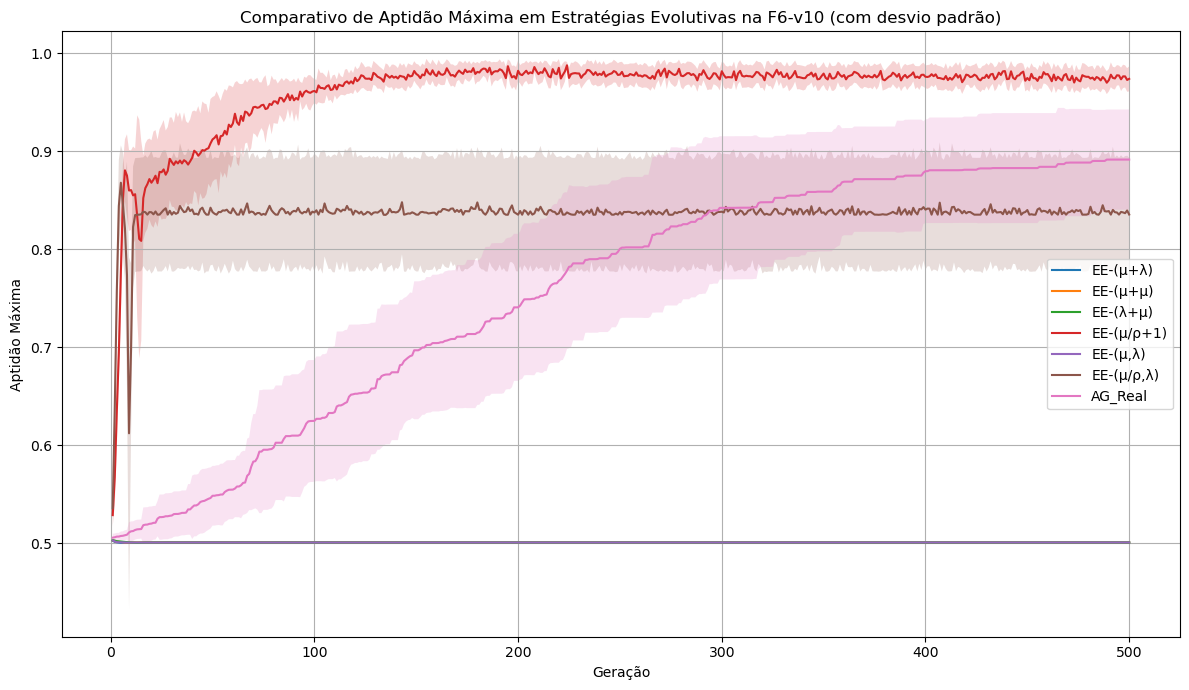

In [155]:
# Plotar Aptidão Máxima
plot_performance(aggregated_data, "max_fitness", 
                 "Comparativo de Aptidão Máxima em Estratégias Evolutivas na F6-v10 (com desvio padrão)", 
                 "Aptidão Máxima", "ES_max-fit_std")

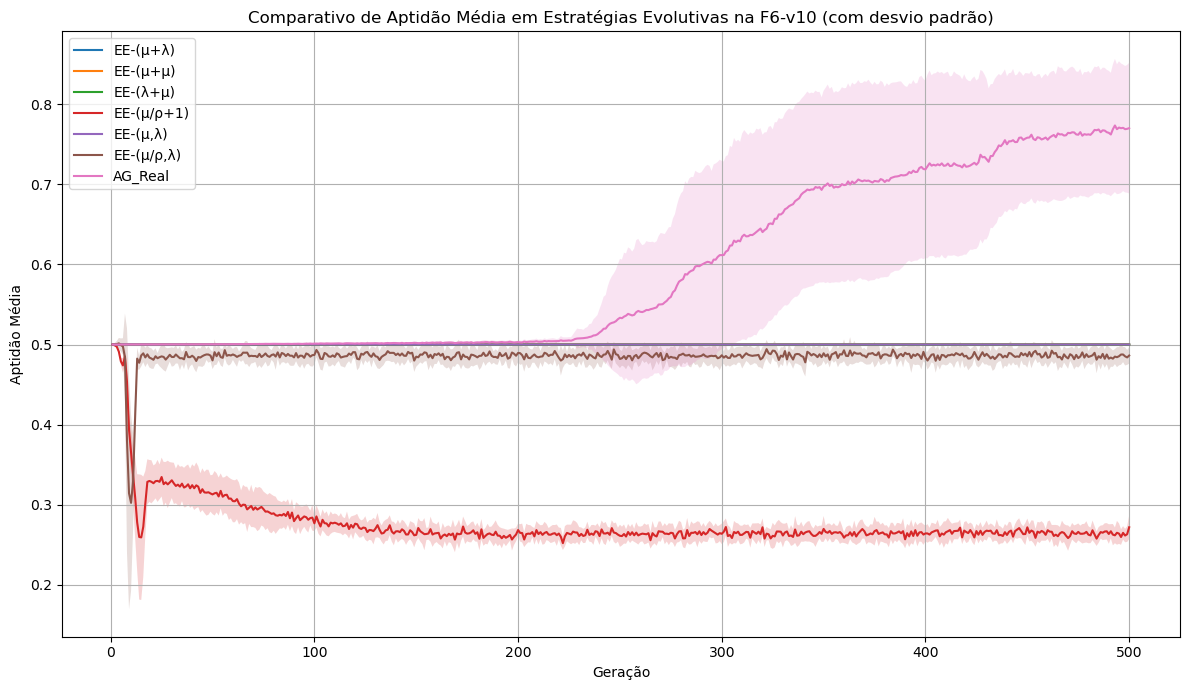

In [156]:
# Plotar Aptidão Média
plot_performance(aggregated_data, "mean_fitness", 
                 "Comparativo de Aptidão Média em Estratégias Evolutivas na F6-v10 (com desvio padrão)", 
                 "Aptidão Média", "ES_mean-fit_std")

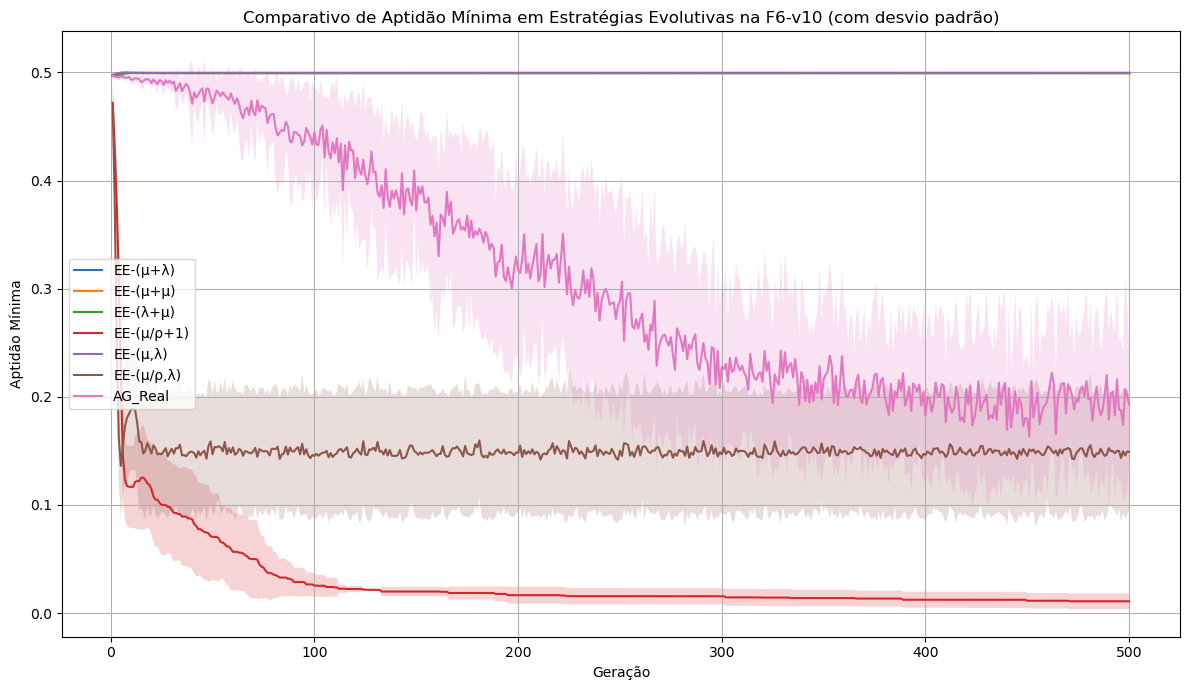

In [157]:
# Plotar Aptidão Mínima
plot_performance(aggregated_data, "min_fitness", 
                 "Comparativo de Aptidão Mínima em Estratégias Evolutivas na F6-v10 (com desvio padrão)", 
                 "Aptidão Mínima", "ES_min-fit_std")

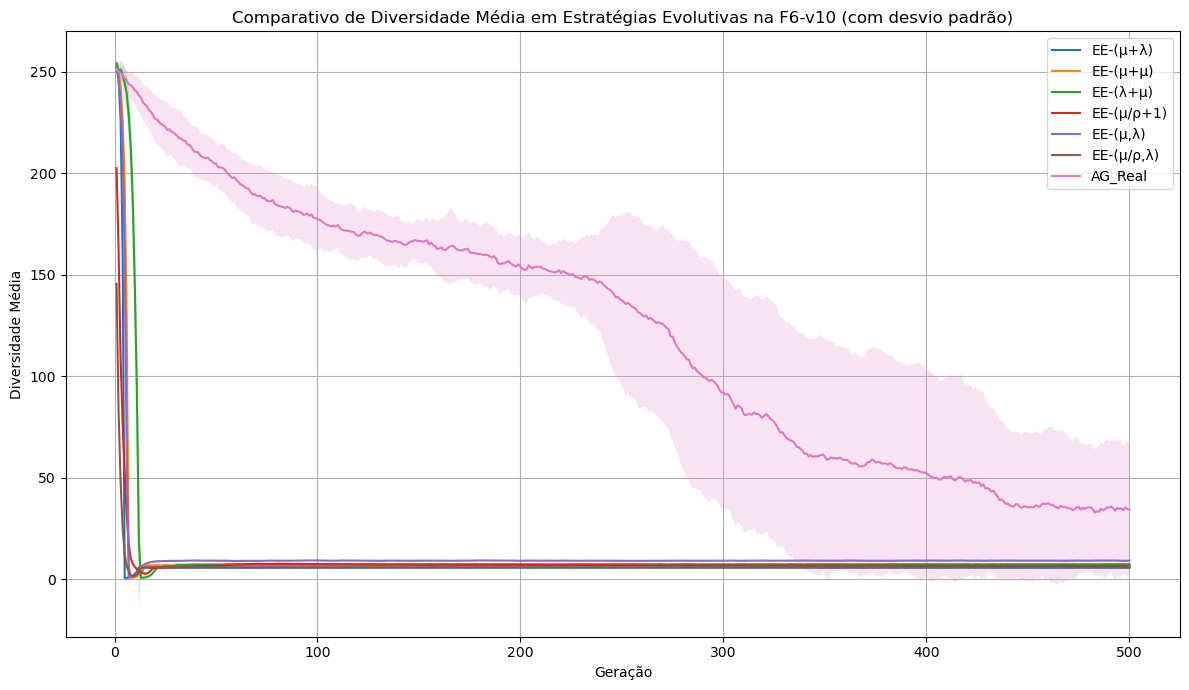

In [159]:
# Plotar Diversidade Média
plot_performance(aggregated_data, "mean_diversity", 
                 "Comparativo de Diversidade Média em Estratégias Evolutivas na F6-v10 (com desvio padrão)", 
                 "Diversidade Média", "ES_mean-diversity_std")